<a href="https://colab.research.google.com/github/Girawale-Sanket/Time-Series-Assignment/blob/main/Time_Series_Analysis_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:
data= pd.read_csv('/content/Intrest Payment data.csv')
data

,Date,Value
0,01-Jan-97,8812.0
1,01-Feb-97,4779.0
2,01-Mar-97,15905.0
3,01-Apr-97,4017.0
4,01-May-97,5950.0
...,...,...
295,01-Aug-21,NaN
296,01-Sep-21,NaN
297,01-Oct-21,NaN
298,01-Nov-21,NaN


In [ ]:
data.shape

(300, 2)

In [ ]:
data.isnull().sum()

,0
Date,0
Value,9


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    300 non-null    object 
 1   Value   291 non-null    float64
dtypes: float64(1), object(1)
memory usage: 4.8+ KB


In [ ]:
data['Date'] = pd.to_datetime(data['Date'], format='%d-%b-%y')

In [ ]:
data['Date'].dtype

dtype('<M8[ns]')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    300 non-null    datetime64[ns]
 1   Value   291 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.8 KB


In [ ]:
data.set_index("Date", inplace=True)

In [ ]:
data = data.sort_values("Date")
data.head()

,Value
Date,
1997-01-01,8812.0
1997-02-01,4779.0
1997-03-01,15905.0
1997-04-01,4017.0
1997-05-01,5950.0


In [ ]:
a=data['Value'].mean()

In [ ]:
a

np.float64(22535.123711340206)

In [ ]:
Y=data['Value'].resample('MS').mean()
Y

,Value
Date,
1997-01-01,8812.0
1997-02-01,4779.0
1997-03-01,15905.0
1997-04-01,4017.0
1997-05-01,5950.0
...,...
2021-08-01,NaN
2021-09-01,NaN
2021-10-01,NaN


In [ ]:
Y.fillna(a, inplace=True)

In [ ]:
Y

,Value
Date,
1997-01-01,8812.000000
1997-02-01,4779.000000
1997-03-01,15905.000000
1997-04-01,4017.000000
1997-05-01,5950.000000
...,...
2021-08-01,22535.123711
2021-09-01,22535.123711
2021-10-01,22535.123711


In [ ]:
Y.isnull().sum()

np.int64(0)

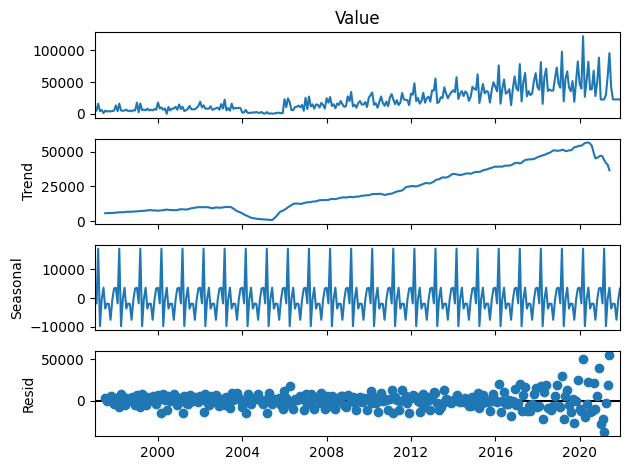

In [ ]:
from pylab import rcParams
decomposition = seasonal_decompose(Y, model='additive')
fig = decomposition.plot()
plt.show()

In [ ]:
for lag in range(1,11):
  print('Lag', lag, ':', Y.corr(Y.shift(lag)))

Lag 1 : 0.5807969295174302
Lag 2 : 0.5859724791351528
Lag 3 : 0.712551828370494
Lag 4 : 0.5359534250254808
Lag 5 : 0.5601749511510621
Lag 6 : 0.76653998563669
Lag 7 : 0.5740662352000291
Lag 8 : 0.5411913311483972
Lag 9 : 0.7369560127711791
Lag 10 : 0.5824420387999092


<Figure size 2000x500 with 0 Axes>

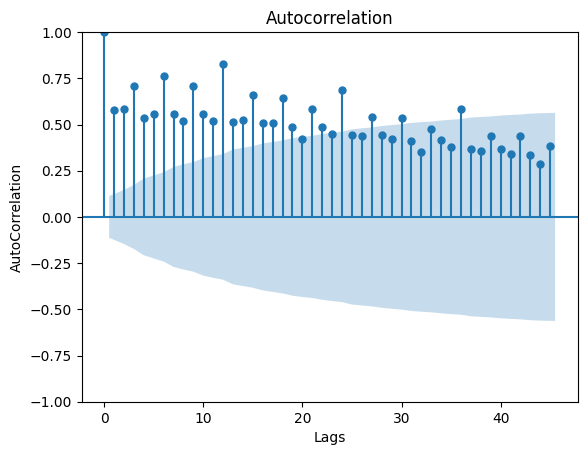

In [ ]:
plt.figure(figsize=(20,5))
plot_acf(Y.dropna(), lags=45)
plt.xlabel('Lags')
plt.ylabel('AutoCorrelation')
plt.show()

<Figure size 2000x500 with 0 Axes>

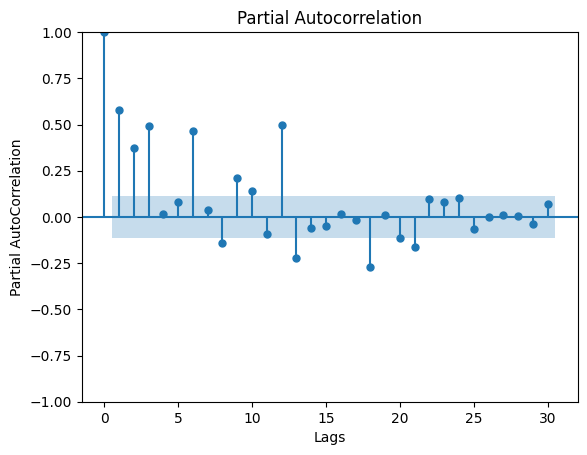

In [ ]:
plt.figure(figsize=(20,5))
plot_pacf(Y.dropna(), lags=30, method='ywm')#ywm= Yule-Walker Method
plt.title('Partial Autocorrelation')
plt.xlabel('Lags')
plt.ylabel('Partial AutoCorrelation')
plt.show()